# Temporal analysis of messages by channel (taking into consideration bias)

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import powerlaw
import textwrap
from lifelines import KaplanMeierFitter

In [3]:
# import dataset
df = pd.read_json("../../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

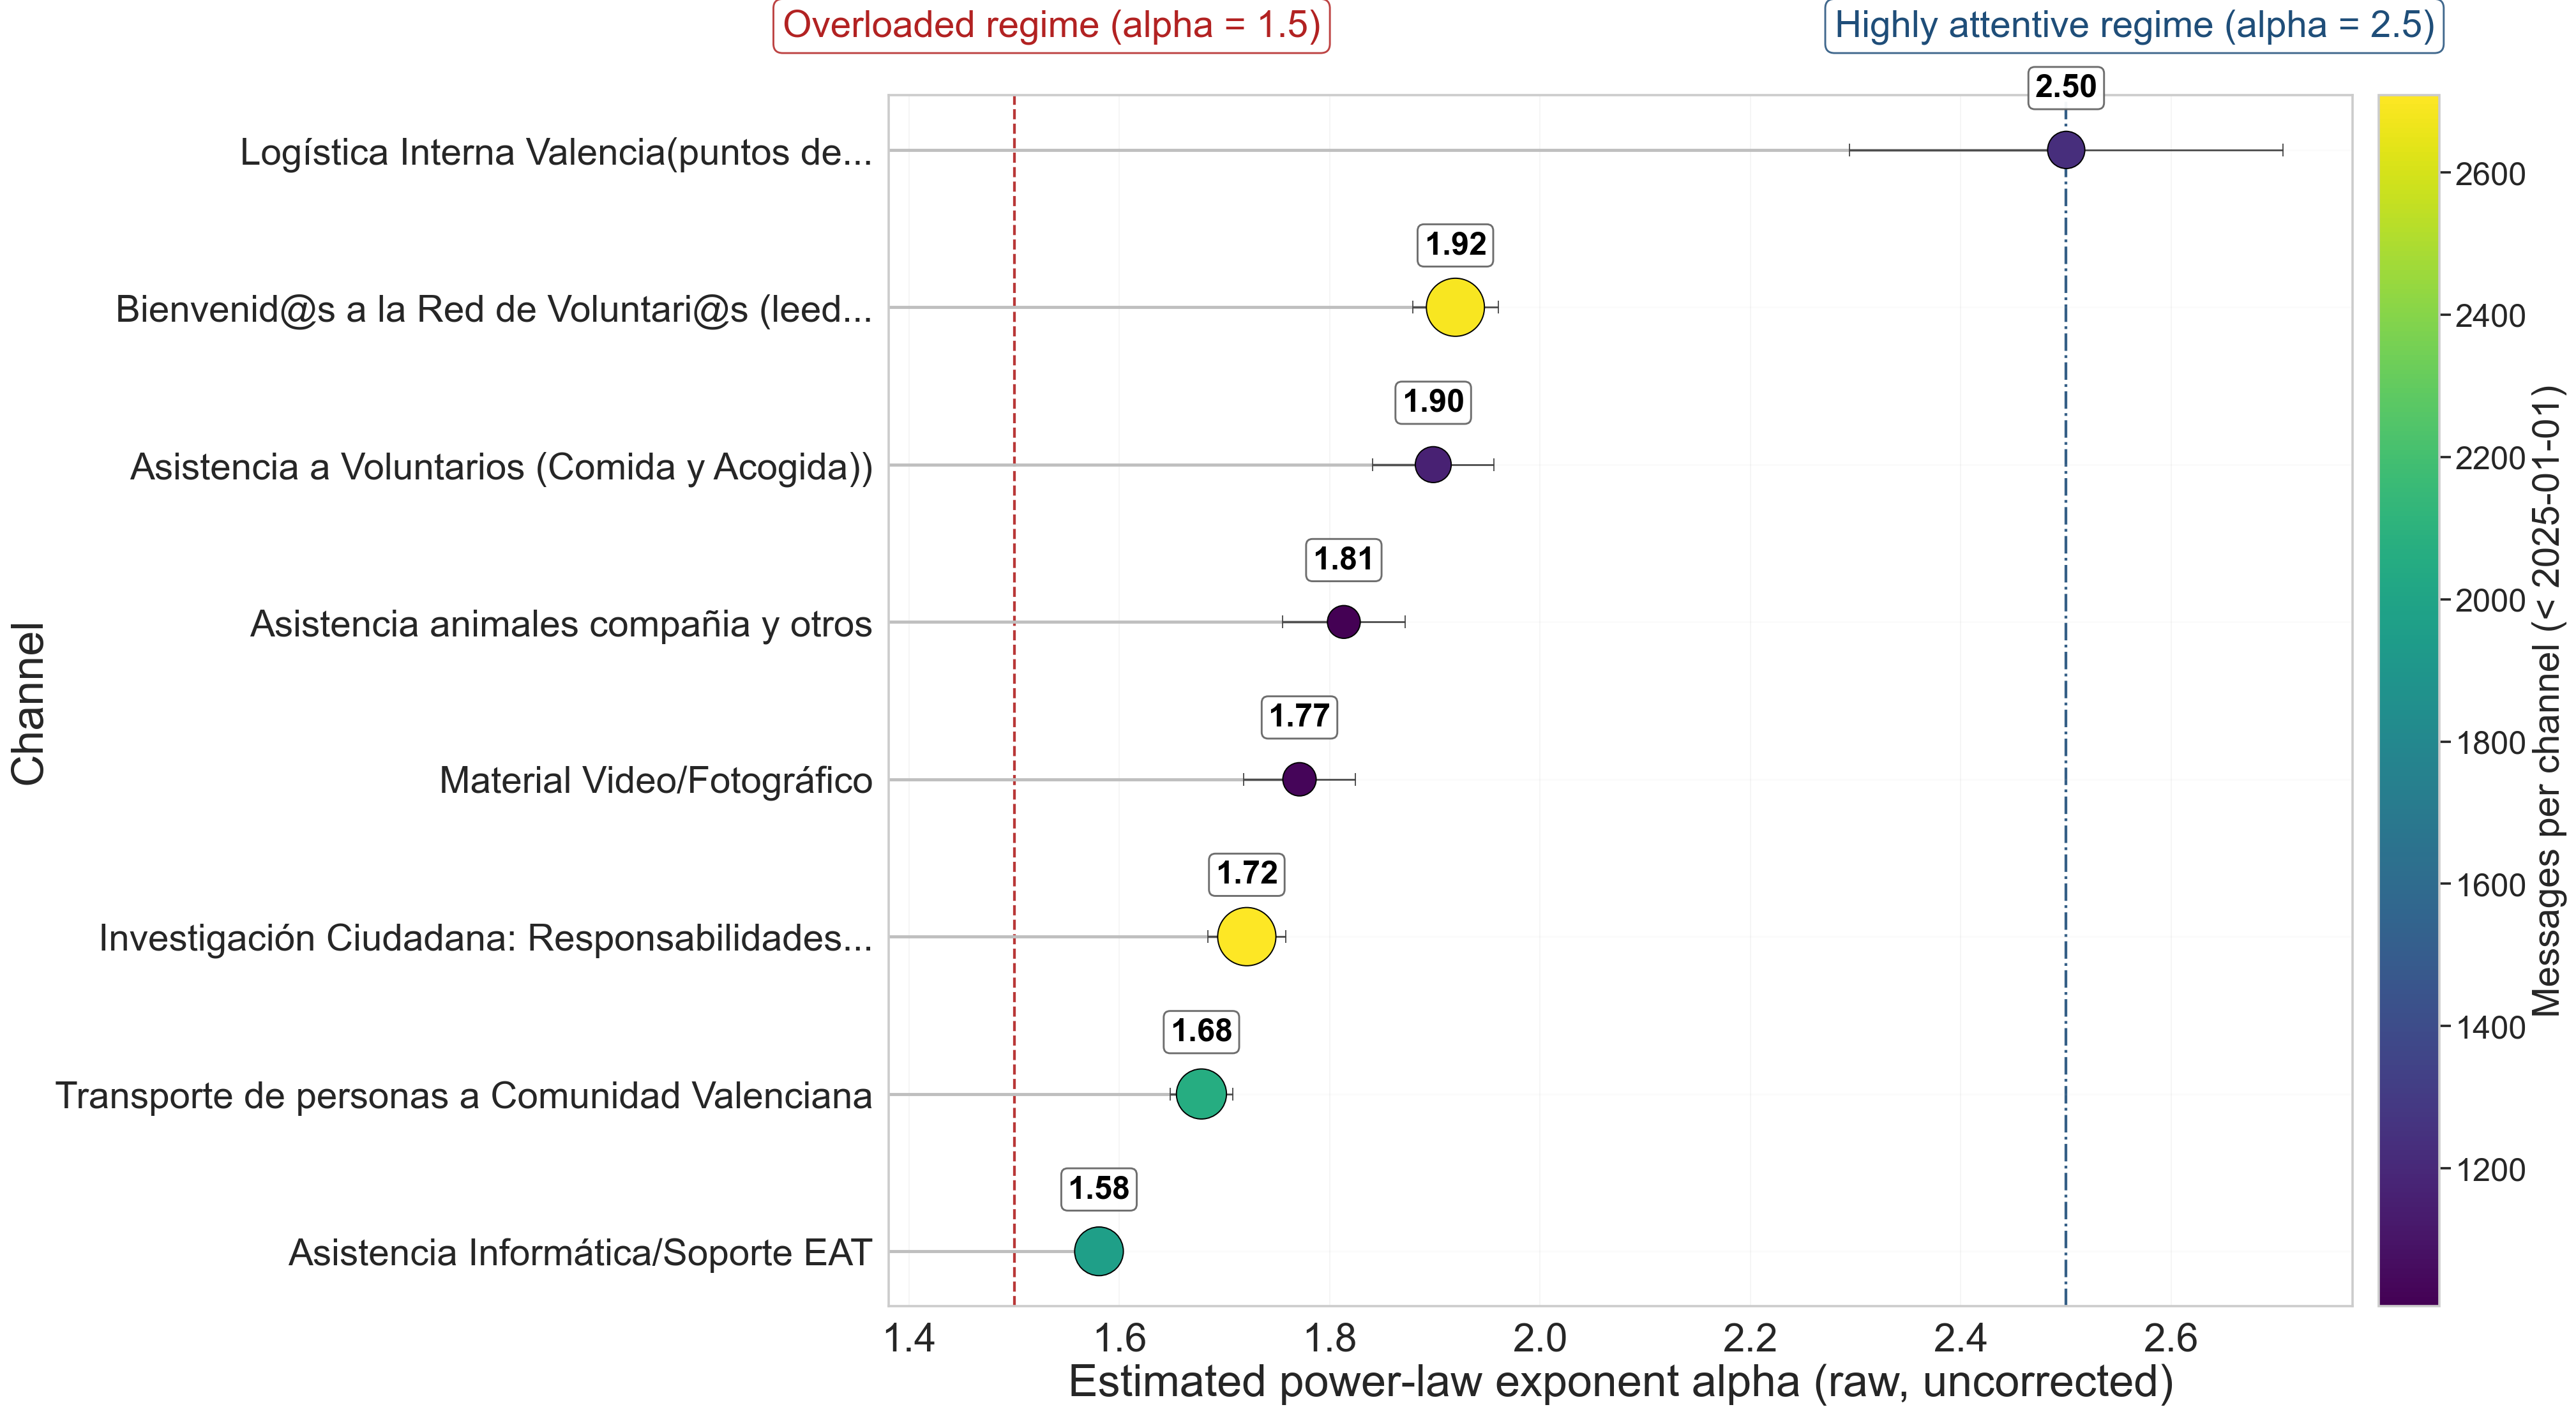

,channel,alpha,alpha_km,bias_sev,sigma,xmin,n_messages,n_waiting,n_tail
0,Asistencia Informática/Soporte EAT,1.580704,1.606669,0.1072,0.021748,66.0,1960,1935,713
1,Transporte de personas a Comunidad Valenciana,1.678092,1.826094,0.0422,0.029794,789.0,2058,1978,518
2,Investigación Ciudadana: Responsabilidades Pol...,1.721214,1.791031,0.0667,0.037095,1208.0,2709,2647,378
3,Material Video/Fotográfico,1.771315,1.897007,0.0507,0.052850,2954.0,1030,881,213
4,Asistencia animales compañia y otros,1.813468,1.899197,0.1693,0.058254,2789.0,1006,877,195
5,Asistencia a Voluntarios (Comida y Acogida)),1.898486,1.908821,0.2393,0.057520,919.0,1163,1135,244
6,Bienvenid@s a la Red de Voluntari@s (leed prim...,1.919537,1.880172,0.1876,0.040798,402.0,2695,2647,508
7,Logística Interna Valencia(puntos de recepción),2.500263,2.619720,0.0808,0.206077,26201.0,1231,1193,53


<Figure size 896x672 with 0 Axes>

In [4]:
# PL analysis: power-law exponents across channels (>1000 msgs), up to 2025-01-01.

# Ensure datetime
df_alpha = df.copy()
df_alpha['date'] = pd.to_datetime(df_alpha['date'], errors='coerce')
df_alpha = df_alpha.dropna(subset=['date', 'topic_name'])

date_tz = df_alpha['date'].dt.tz
cutoff_date = pd.Timestamp('2025-01-01', tz=date_tz) if date_tz is not None else pd.Timestamp('2025-01-01')
df_alpha = df_alpha[df_alpha['date'] < cutoff_date].copy()

channel_sizes = df_alpha.groupby('topic_name').size().sort_values(ascending=False)
eligible_channels = channel_sizes[channel_sizes > 1000].index

results = []
for channel in eligible_channels:
    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    # KM correction (before subsampling — needs all IETs)
    T_seconds = (cutoff_date - ch['date'].iloc[0]).total_seconds()
    tau_fc    = max((cutoff_date - ch['date'].iloc[-1]).total_seconds(), 0.0)
    bias_sev  = waiting.max() / T_seconds

    iet_vals = waiting.values
    km_dur   = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs   = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))

    if len(waiting) < 100:
        continue
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        fit   = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        pl    = fit.power_law
        alpha = float(getattr(pl, 'alpha', np.nan))
        sigma = float(getattr(pl, 'sigma', np.nan))
        xmin  = float(getattr(pl, 'xmin', np.nan))
        n_tail = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        # KM-corrected alpha via log-log regression on survival curve (PL)
        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)
        if np.isfinite(xmin) and mask.sum() > 5:
            slope, _ = np.polyfit(np.log(km_t[mask]), np.log(km_s[mask]), 1)
            alpha_km = float(1.0 - slope)  # S(τ) ~ τ^{-(α-1)}
        else:
            alpha_km = np.nan

        if np.isfinite(alpha):
            results.append({
                'channel':    channel,
                'alpha':      alpha,
                'alpha_km':   alpha_km,
                'bias_sev':   round(bias_sev, 4),
                'sigma':      sigma if np.isfinite(sigma) else np.nan,
                'xmin':       xmin,
                'n_messages': int(channel_sizes[channel]),
                'n_waiting':  int(len(waiting)),
                'n_tail':     n_tail
            })
    except Exception as exc:
        print(f"Skipping channel: {channel} -> {exc}")

alpha_df = pd.DataFrame(results).sort_values('alpha', ascending=True).reset_index(drop=True)

if alpha_df.empty:
    raise ValueError('No valid alpha estimates could be computed.')

alpha_df['channel_label'] = alpha_df['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# --- Poster: PL (raw, uncorrected) ---
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_df['alpha'].min() - 0.2)
for i, row in alpha_df.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_df['n_messages'],
                  (alpha_df['n_messages'].min(), alpha_df['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_df['alpha'], np.arange(len(alpha_df)),
                     s=sizes, c=alpha_df['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_df['sigma'].notna()
ax.errorbar(alpha_df.loc[valid_sigma, 'alpha'], np.where(valid_sigma)[0],
            xerr=alpha_df.loc[valid_sigma, 'sigma'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_df) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_df) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_df)))
ax.set_yticklabels(alpha_df['channel_label'], fontsize=30)
ax.set_xlabel('Estimated power-law exponent alpha (raw, uncorrected)', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_df.iterrows():
    ax.annotate(f"{row['alpha']:.2f}", (row['alpha'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_pl_poster.svg', format='svg', bbox_inches='tight')

alpha_df[['channel', 'alpha', 'alpha_km', 'bias_sev', 'sigma', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

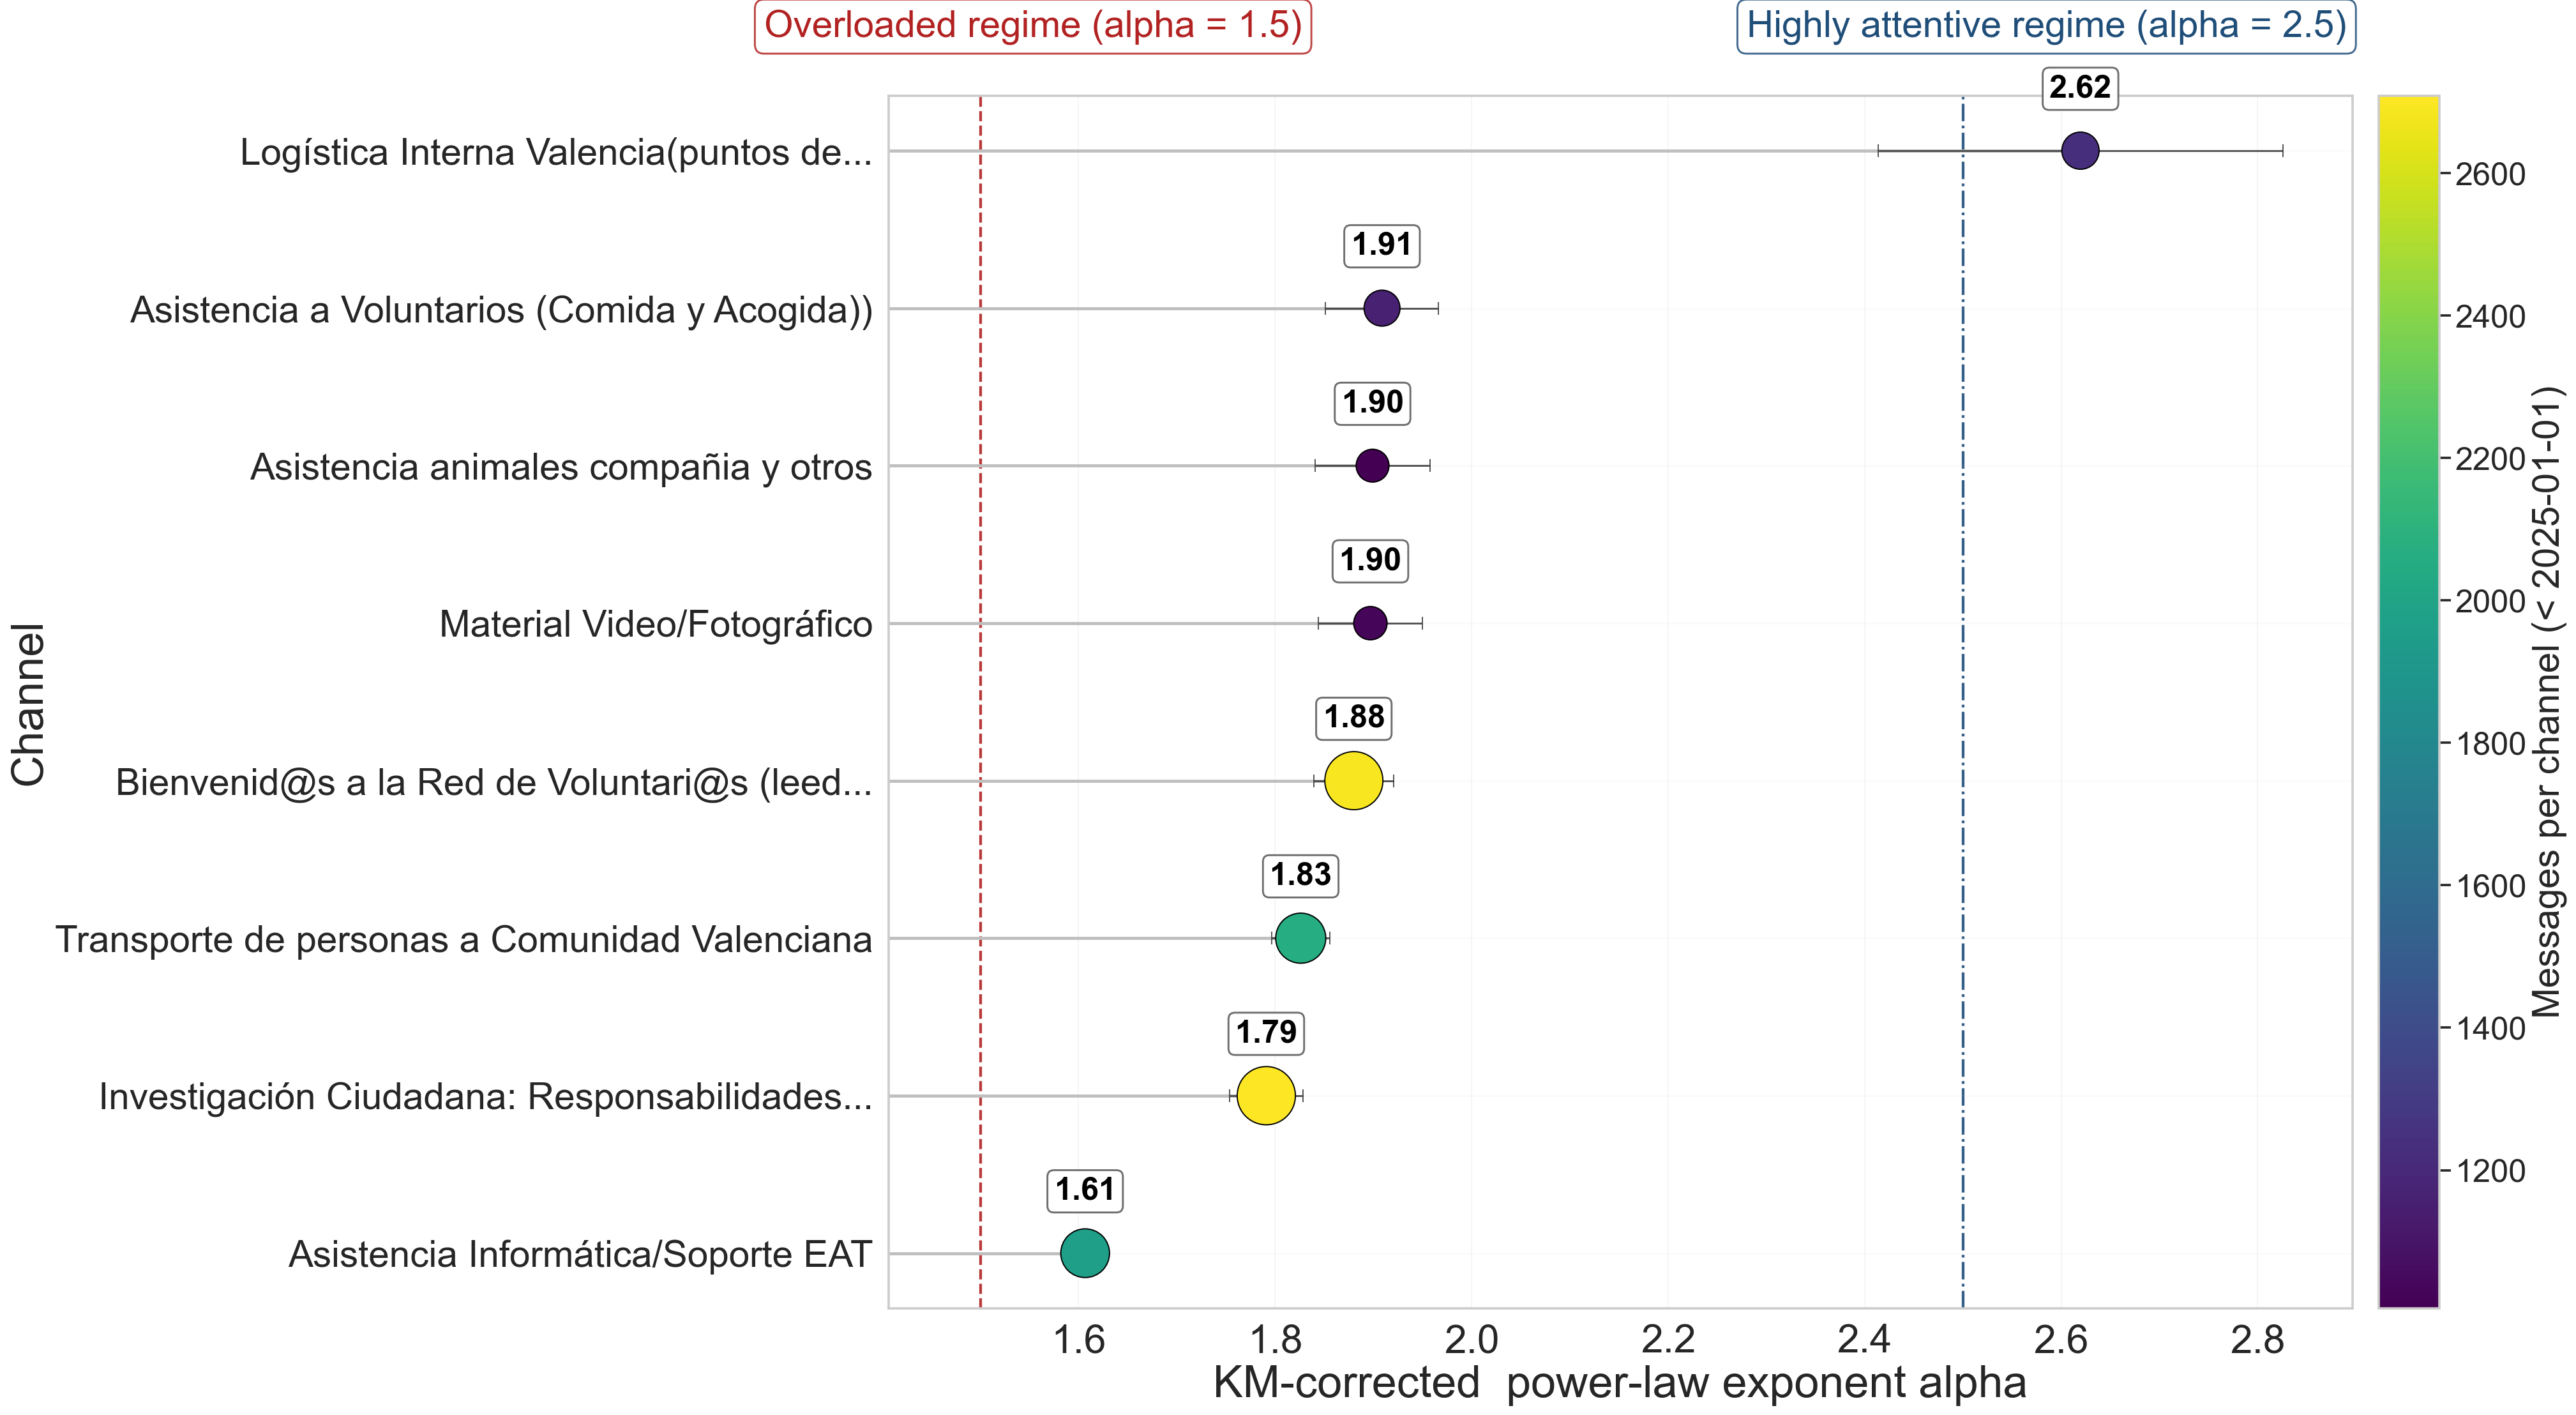

<Figure size 896x672 with 0 Axes>

In [5]:

    # Same poster-style lollipop chart but using KM-corrected alpha (finite-size-bias corrected)

# Drop rows where alpha_km is NaN (fit didn't converge)
alpha_km_df = alpha_df.dropna(subset=['alpha_km']).sort_values('alpha_km', ascending=True).reset_index(drop=True)
alpha_km_df['channel_label'] = alpha_km_df['channel'].apply(
    lambda s: __import__('textwrap').shorten(str(s), width=46, placeholder='...')
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'axes.titlesize': 42,
    'axes.labelsize': 36,
    'xtick.labelsize': 32,
    'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_km_df['alpha_km'].min() - 0.2)
for i, row in alpha_km_df.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_km'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(
    alpha_km_df['n_messages'],
    (alpha_km_df['n_messages'].min(), alpha_km_df['n_messages'].max()),
    (700, 2200)
)

scatter = ax.scatter(
    alpha_km_df['alpha_km'],
    np.arange(len(alpha_km_df)),
    s=sizes,
    c=alpha_km_df['n_messages'],
    cmap='viridis',
    edgecolor='black',
    linewidth=1.0,
    zorder=3
)

# Uncertainty bars: reuse sigma from raw fit (same xmin region)
valid_sigma = alpha_km_df['sigma'].notna()
ax.errorbar(
    alpha_km_df.loc[valid_sigma, 'alpha_km'],
    np.where(valid_sigma)[0],
    xerr=alpha_km_df.loc[valid_sigma, 'sigma'],
    fmt='none',
    ecolor='0.25',
    elinewidth=1.5,
    capsize=5,
    zorder=2,
    alpha=0.9
)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)

ax.text(
    1.28, len(alpha_km_df) - 0.1, 'Overloaded regime (alpha = 1.5)',
    color='#B22222', fontsize=30, va='top', ha='left',
    bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25')
)
ax.text(
    2.28, len(alpha_km_df) - 0.1, 'Highly attentive regime (alpha = 2.5)',
    color='#1F4E79', fontsize=30, va='top', ha='left',
    bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25')
)

ax.set_yticks(np.arange(len(alpha_km_df)))
ax.set_yticklabels(alpha_km_df['channel_label'], fontsize=30)
ax.set_xlabel('KM-corrected  power-law exponent alpha', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_km_df.iterrows():
    ax.annotate(
        f"{row['alpha_km']:.2f}",
        (row['alpha_km'], i),
        xytext=(0, 38),
        textcoords='offset points',
        va='bottom', ha='center',
        fontsize=26, color='black', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2')
    )

plt.tight_layout()
plt.show()
plt.savefig('alpha_km_comparison_poster_normal.svg', format='svg', bbox_inches='tight')


## Finite size bias comparison

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


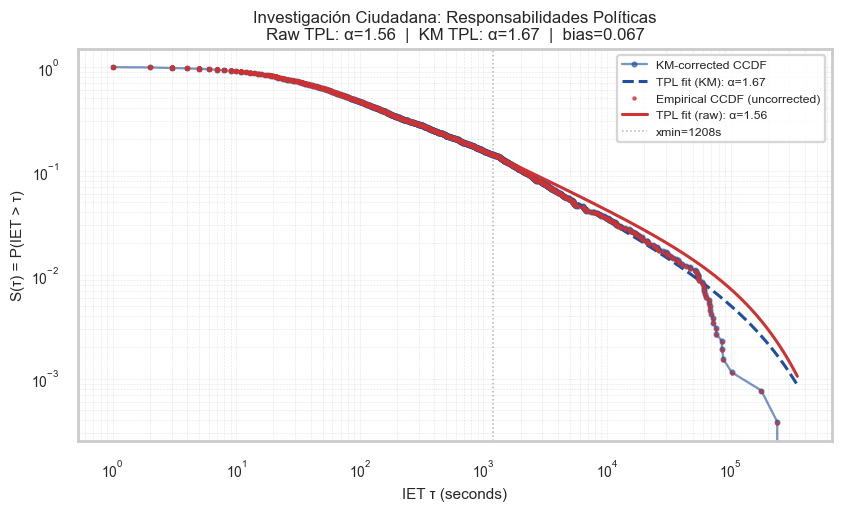

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


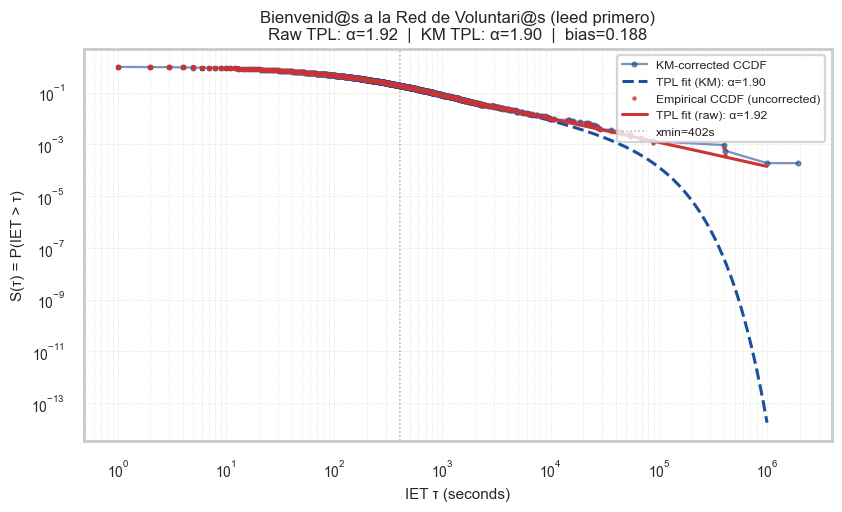

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


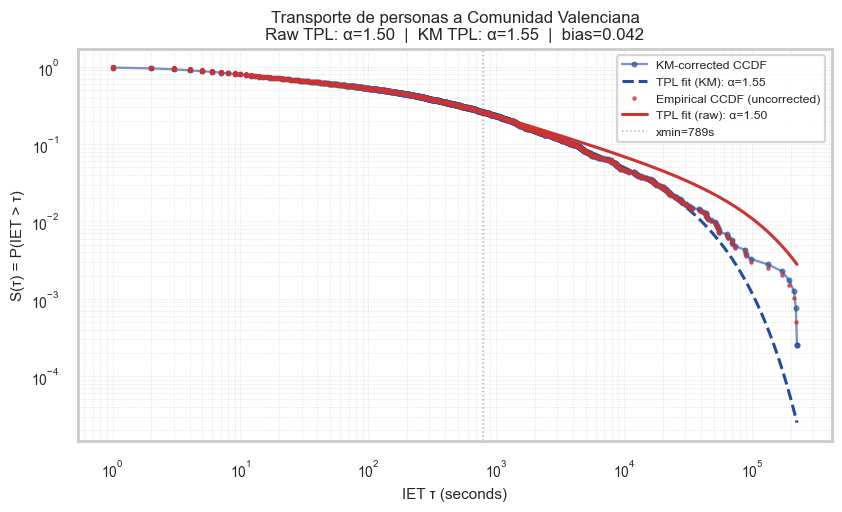

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


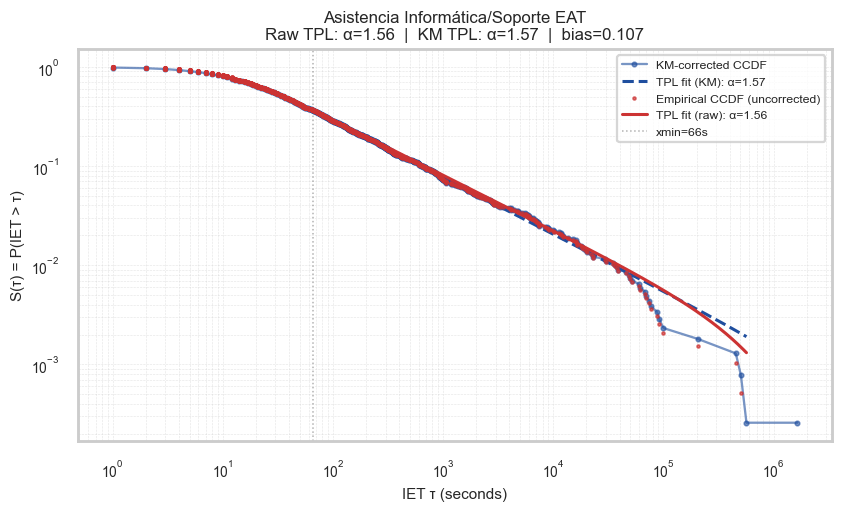

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


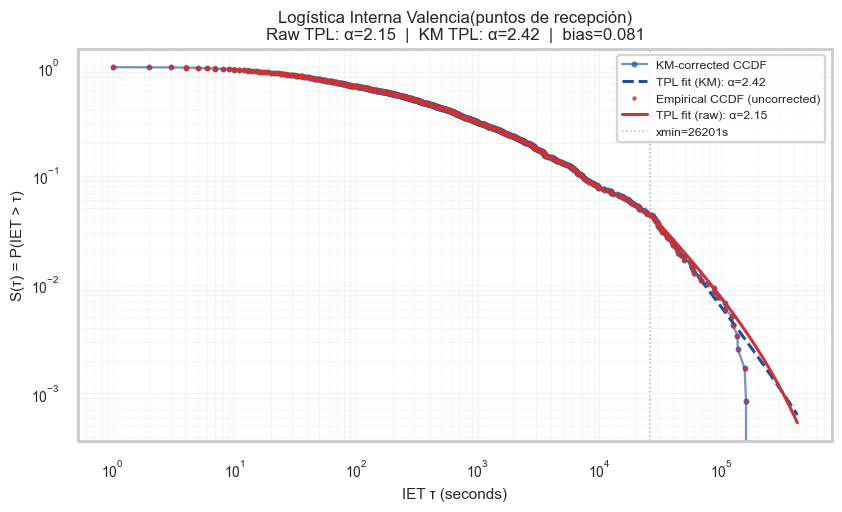

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


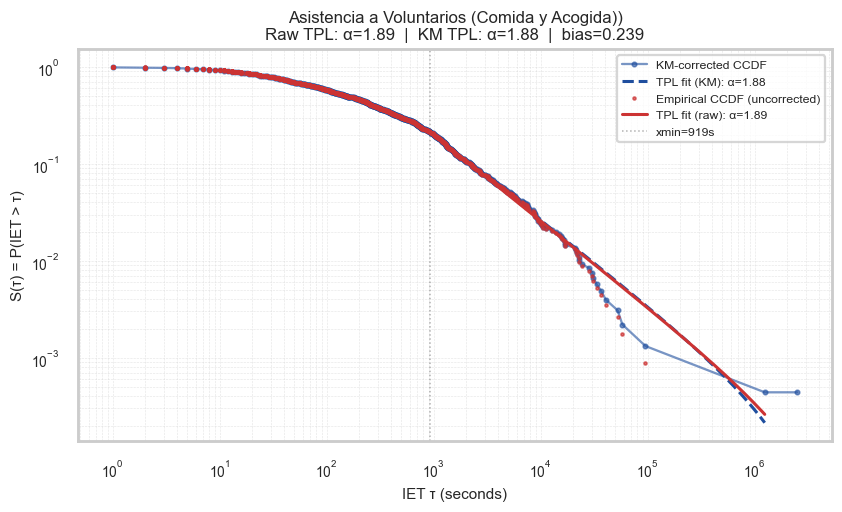

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


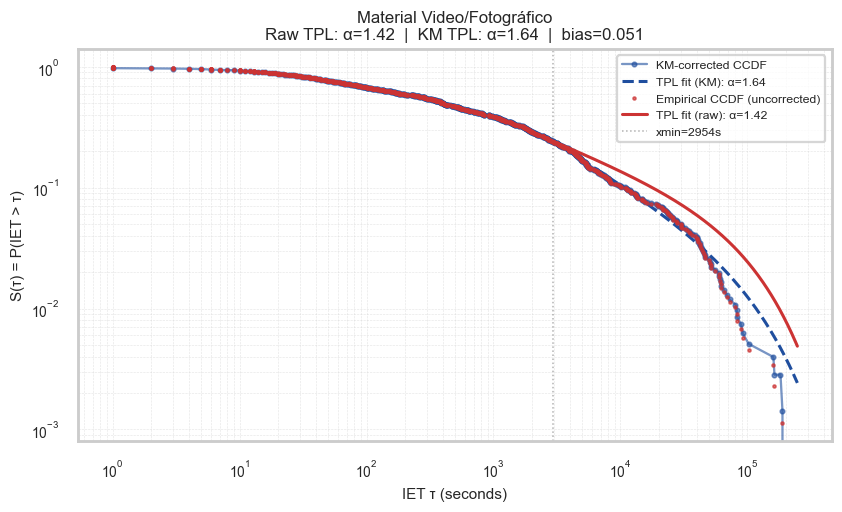

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


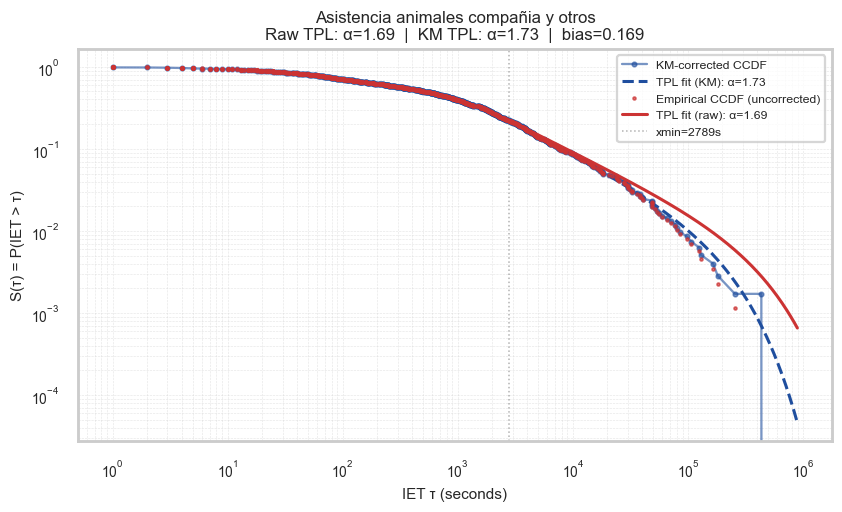

In [6]:
# data by channel: CCDF taking into account finite size bias with KM correction and not
from scipy.optimize import curve_fit

for channel in eligible_channels:
    results_channel = alpha_df[alpha_df['channel'] == channel]
    if results_channel.empty:
        continue

    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]
    if len(waiting) < 20:
        continue

    iet_vals = waiting.values
    xmin_val = float(results_channel['xmin'].values[0])
    alpha_km_val = float(results_channel['alpha_km'].values[0])
    bias = float(results_channel['bias_sev'].values[0])

    # --- KM correction ---
    tau_fc = max((cutoff_date - ch['date'].iloc[-1]).total_seconds(), 0.0)
    km_dur = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))
    km_t = kmf.survival_function_.index.values
    km_s = kmf.survival_function_['KM_estimate'].values

    # --- Empirical CCDF (uncorrected) ---
    sorted_iet = np.sort(iet_vals)
    n = len(sorted_iet)
    emp_surv = (n - np.arange(1, n + 1)) / n
    emp_mask = emp_surv > 0
    s_at_xmin_emp = (iet_vals >= xmin_val).sum() / n

    # --- Truncated power-law fit to uncorrected data ---
    fit_raw = powerlaw.Fit(iet_vals, xmin=xmin_val, discrete=True, verbose=False)
    tpl_raw = fit_raw.truncated_power_law
    alpha_tpl = tpl_raw.alpha
    Lambda_tpl = tpl_raw.parameter2

    # --- Truncated power-law fit to KM-corrected tail ---
    mask_km = (km_t >= xmin_val) & (km_s > 0) & (km_t > 0)
    alpha_tpl_km = np.nan
    Lambda_tpl_km = np.nan
    if mask_km.sum() > 5:
        km_t_tail = km_t[mask_km]
        km_s_norm = km_s[mask_km] / km_s[mask_km][0]

        def tpl_surv(t, alpha, lam):
            return (t / xmin_val) ** (-(alpha - 1)) * np.exp(-(t - xmin_val) * lam)

        try:
            popt, _ = curve_fit(
                tpl_surv, km_t_tail, km_s_norm,
                p0=[max(alpha_km_val, 1.01), 1.0 / iet_vals.max()],
                bounds=([1.001, 0.0], [20.0, np.inf]),
                maxfev=10000
            )
            alpha_tpl_km, Lambda_tpl_km = popt
        except Exception:
            pass

    t_fit = np.logspace(np.log10(xmin_val), np.log10(sorted_iet.max()), 300)

    # Use rc_context to isolate font sizes from the poster cell above
    with plt.rc_context({
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 8,
        'figure.dpi': 110,
    }):
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.set_title(
            f"{channel}\n"
            f"Raw TPL: α={alpha_tpl:.2f}  |  KM TPL: α={alpha_tpl_km:.2f}  |  bias={bias:.3f}"
        )
        ax.set_xlabel('IET τ (seconds)')
        ax.set_ylabel('S(τ) = P(IET > τ)')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.5)

        # --- Plot KM first (background) ---
        mask_pos = km_t > 0
        ax.plot(km_t[mask_pos], km_s[mask_pos],
                'o-', color='#1F4E9E', markersize=3, lw=1.5, alpha=0.6,
                label='KM-corrected CCDF', zorder=2)

        if not np.isnan(alpha_tpl_km) and not np.isnan(Lambda_tpl_km):
            s_at_xmin_km = km_s[mask_km][0]
            s_fit_km = ((t_fit / xmin_val) ** (-(alpha_tpl_km - 1))
                        * np.exp(-(t_fit - xmin_val) * Lambda_tpl_km)
                        * s_at_xmin_km)
            ax.plot(t_fit, s_fit_km, '--', color='#1F4E9E', lw=2,
                    label=f'TPL fit (KM): α={alpha_tpl_km:.2f}', zorder=3)

        # --- Plot empirical on top (foreground) ---
        ax.plot(sorted_iet[emp_mask], emp_surv[emp_mask],
                '.', color='#CC3333', markersize=4, alpha=0.7,
                label='Empirical CCDF (uncorrected)', zorder=4)

        s_fit_raw = ((t_fit / xmin_val) ** (-(alpha_tpl - 1))
                     * np.exp(-(t_fit - xmin_val) * Lambda_tpl)
                     * s_at_xmin_emp)
        ax.plot(t_fit, s_fit_raw, '-', color='#CC3333', lw=2,
                label=f'TPL fit (raw): α={alpha_tpl:.2f}', zorder=5)

        ax.axvline(xmin_val, color='gray', lw=1, ls=':', alpha=0.6,
                   label=f'xmin={xmin_val:.0f}s', zorder=1)
        ax.legend(loc='upper right')
        plt.tight_layout()
        plt.show()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


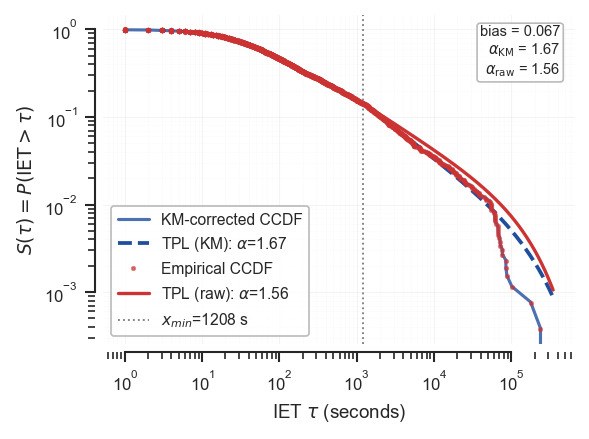

Saved figures/ccdf_paper/paper_ccdf_Investigación_Ciudadana:_Responsabilidades_Políticas.pdf


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


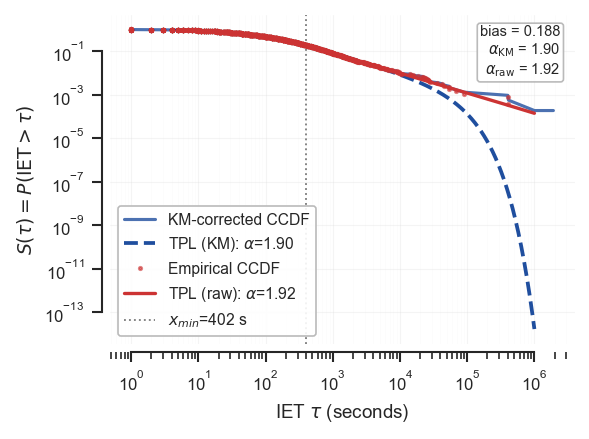

Saved figures/ccdf_paper/paper_ccdf_Bienvenid@s_a_la_Red_de_Voluntari@s_(leed_primero).pdf


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


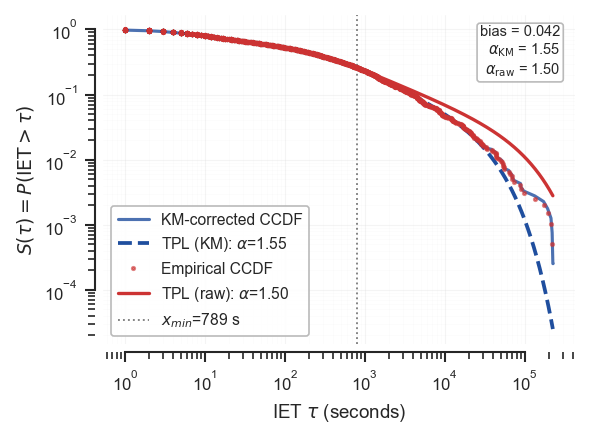

Saved figures/ccdf_paper/paper_ccdf_Transporte_de_personas_a_Comunidad_Valenciana.pdf


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


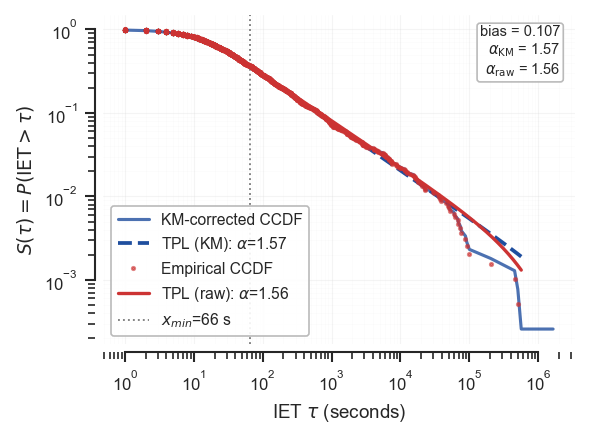

Saved figures/ccdf_paper/paper_ccdf_Asistencia_Informática_Soporte_EAT.pdf


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


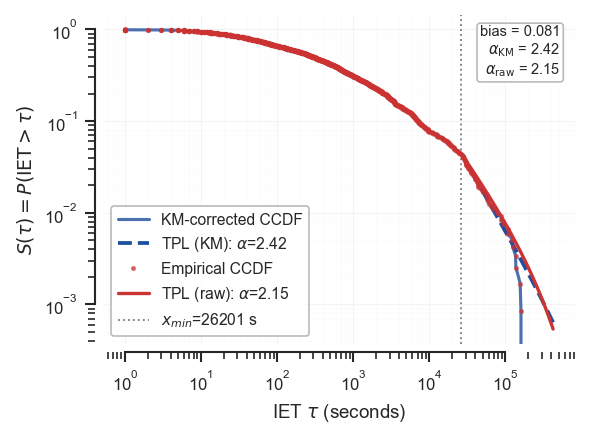

Saved figures/ccdf_paper/paper_ccdf_Logística_Interna_Valencia(puntos_de_recepción).pdf


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


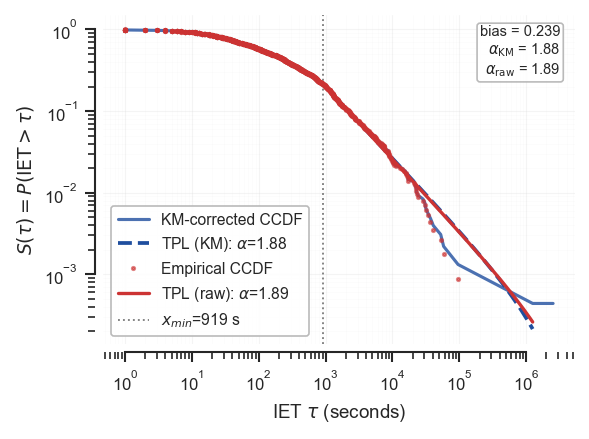

Saved figures/ccdf_paper/paper_ccdf_Asistencia_a_Voluntarios_(Comida_y_Acogida)).pdf


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


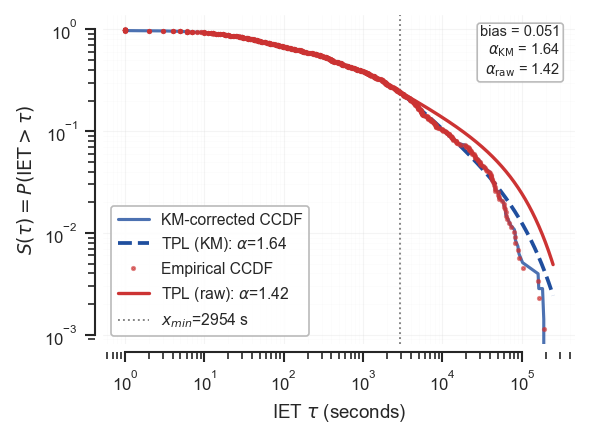

Saved figures/ccdf_paper/paper_ccdf_Material_Video_Fotográfico.pdf


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


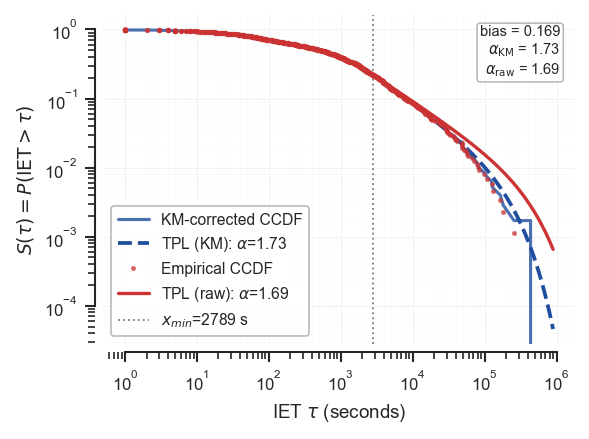

Saved figures/ccdf_paper/paper_ccdf_Asistencia_animales_compañia_y_otros.pdf


In [7]:
# Paper-ready CCDF figures (one PDF per channel)
import os, seaborn as sns, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import numpy as np

os.makedirs('figures/ccdf_paper', exist_ok=True)

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7.5, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

C_KM  = '#1F4E9E'   # blue  — KM-corrected
C_EMP = '#CC3333'   # red   — empirical (raw)

for channel in eligible_channels:
    results_channel = alpha_df[alpha_df['channel'] == channel]
    if results_channel.empty:
        continue

    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]
    if len(waiting) < 20:
        continue

    iet_vals  = waiting.values
    xmin_val  = float(results_channel['xmin'].values[0])
    alpha_km_val = float(results_channel['alpha_km'].values[0])
    bias      = float(results_channel['bias_sev'].values[0])

    # KM survival
    from lifelines import KaplanMeierFitter
    tau_fc = max((cutoff_date - ch['date'].iloc[-1]).total_seconds(), 0.0)
    km_dur = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))
    km_t = kmf.survival_function_.index.values
    km_s = kmf.survival_function_['KM_estimate'].values

    # Empirical CCDF
    sorted_iet = np.sort(iet_vals)
    n = len(sorted_iet)
    emp_surv = (n - np.arange(1, n + 1)) / n
    emp_mask = emp_surv > 0
    s_at_xmin_emp = (iet_vals >= xmin_val).sum() / n

    # Raw TPL fit
    fit_raw = powerlaw.Fit(iet_vals, xmin=xmin_val, discrete=True, verbose=False)
    tpl_raw = fit_raw.truncated_power_law
    alpha_tpl   = tpl_raw.alpha
    Lambda_tpl  = tpl_raw.parameter2

    # KM TPL fit
    from scipy.optimize import curve_fit
    mask_km = (km_t >= xmin_val) & (km_s > 0) & (km_t > 0)
    alpha_tpl_km = np.nan; Lambda_tpl_km = np.nan
    if mask_km.sum() > 5:
        km_t_tail = km_t[mask_km]
        km_s_norm = km_s[mask_km] / km_s[mask_km][0]
        def tpl_surv(t, alpha, lam):
            return (t / xmin_val)**(-(alpha-1)) * np.exp(-(t-xmin_val)*lam)
        try:
            popt, _ = curve_fit(tpl_surv, km_t_tail, km_s_norm,
                                p0=[max(alpha_km_val, 1.01), 1.0/iet_vals.max()],
                                bounds=([1.001, 0.0],[20.0, np.inf]), maxfev=10000)
            alpha_tpl_km, Lambda_tpl_km = popt
        except Exception:
            pass

    t_fit = np.logspace(np.log10(xmin_val), np.log10(sorted_iet.max()), 400)

    fig, ax = plt.subplots(figsize=(4.0, 3.0))

    # KM CCDF
    mask_pos = km_t > 0
    ax.plot(km_t[mask_pos], km_s[mask_pos],
            '-', color=C_KM, lw=1.5, alpha=0.8,
            label='KM-corrected CCDF', zorder=2)

    # KM TPL fit
    if not (np.isnan(alpha_tpl_km) or np.isnan(Lambda_tpl_km)):
        s_at_xmin_km = km_s[mask_km][0]
        s_fit_km = ((t_fit/xmin_val)**(-(alpha_tpl_km-1))
                    * np.exp(-(t_fit-xmin_val)*Lambda_tpl_km)
                    * s_at_xmin_km)
        ax.plot(t_fit, s_fit_km, '--', color=C_KM, lw=1.8,
                label=rf'TPL (KM): $\alpha$={alpha_tpl_km:.2f}', zorder=3)

    # Empirical CCDF
    ax.plot(sorted_iet[emp_mask], emp_surv[emp_mask],
            '.', color=C_EMP, ms=3, alpha=0.6,
            label='Empirical CCDF', zorder=4)

    # Raw TPL fit
    s_fit_raw = ((t_fit/xmin_val)**(-(alpha_tpl-1))
                 * np.exp(-(t_fit-xmin_val)*Lambda_tpl)
                 * s_at_xmin_emp)
    ax.plot(t_fit, s_fit_raw, '-', color=C_EMP, lw=1.6,
            label=rf'TPL (raw): $\alpha$={alpha_tpl:.2f}', zorder=5)

    # xmin line
    ax.axvline(xmin_val, color='0.5', lw=0.9, ls=':', zorder=1,
               label=f'$x_{{min}}$={xmin_val:.0f} s')

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(r'IET $\tau$ (seconds)')
    ax.set_ylabel(r'$S(\tau) = P(\mathrm{IET} > \tau)$')

    # KS stat annotation
    ann = (rf'bias = {bias:.3f}' + '\n'
           + rf'$\alpha_{{\rm KM}}$ = {alpha_tpl_km:.2f}' + '\n'
           + rf'$\alpha_{{\rm raw}}$ = {alpha_tpl:.2f}')
    ax.text(0.97, 0.97, ann, transform=ax.transAxes,
            fontsize=7, va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.9, boxstyle='round,pad=0.2'))

    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.yaxis.set_major_locator(LogLocator(base=10))
    ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.grid(which='major', alpha=0.2, lw=0.5)
    ax.grid(which='minor', alpha=0.08, lw=0.3)
    ax.legend(loc='lower left', framealpha=0.9, edgecolor='0.7')
    sns.despine(ax=ax, trim=True, offset=4)

    fig.tight_layout()
    safe_name = channel.replace('/', '_').replace(' ', '_').replace(',', '').replace('.', '')
    out = f'figures/ccdf_paper/paper_ccdf_{safe_name}.pdf'
    fig.savefig(out, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Saved {out}")


### Truncated power law

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

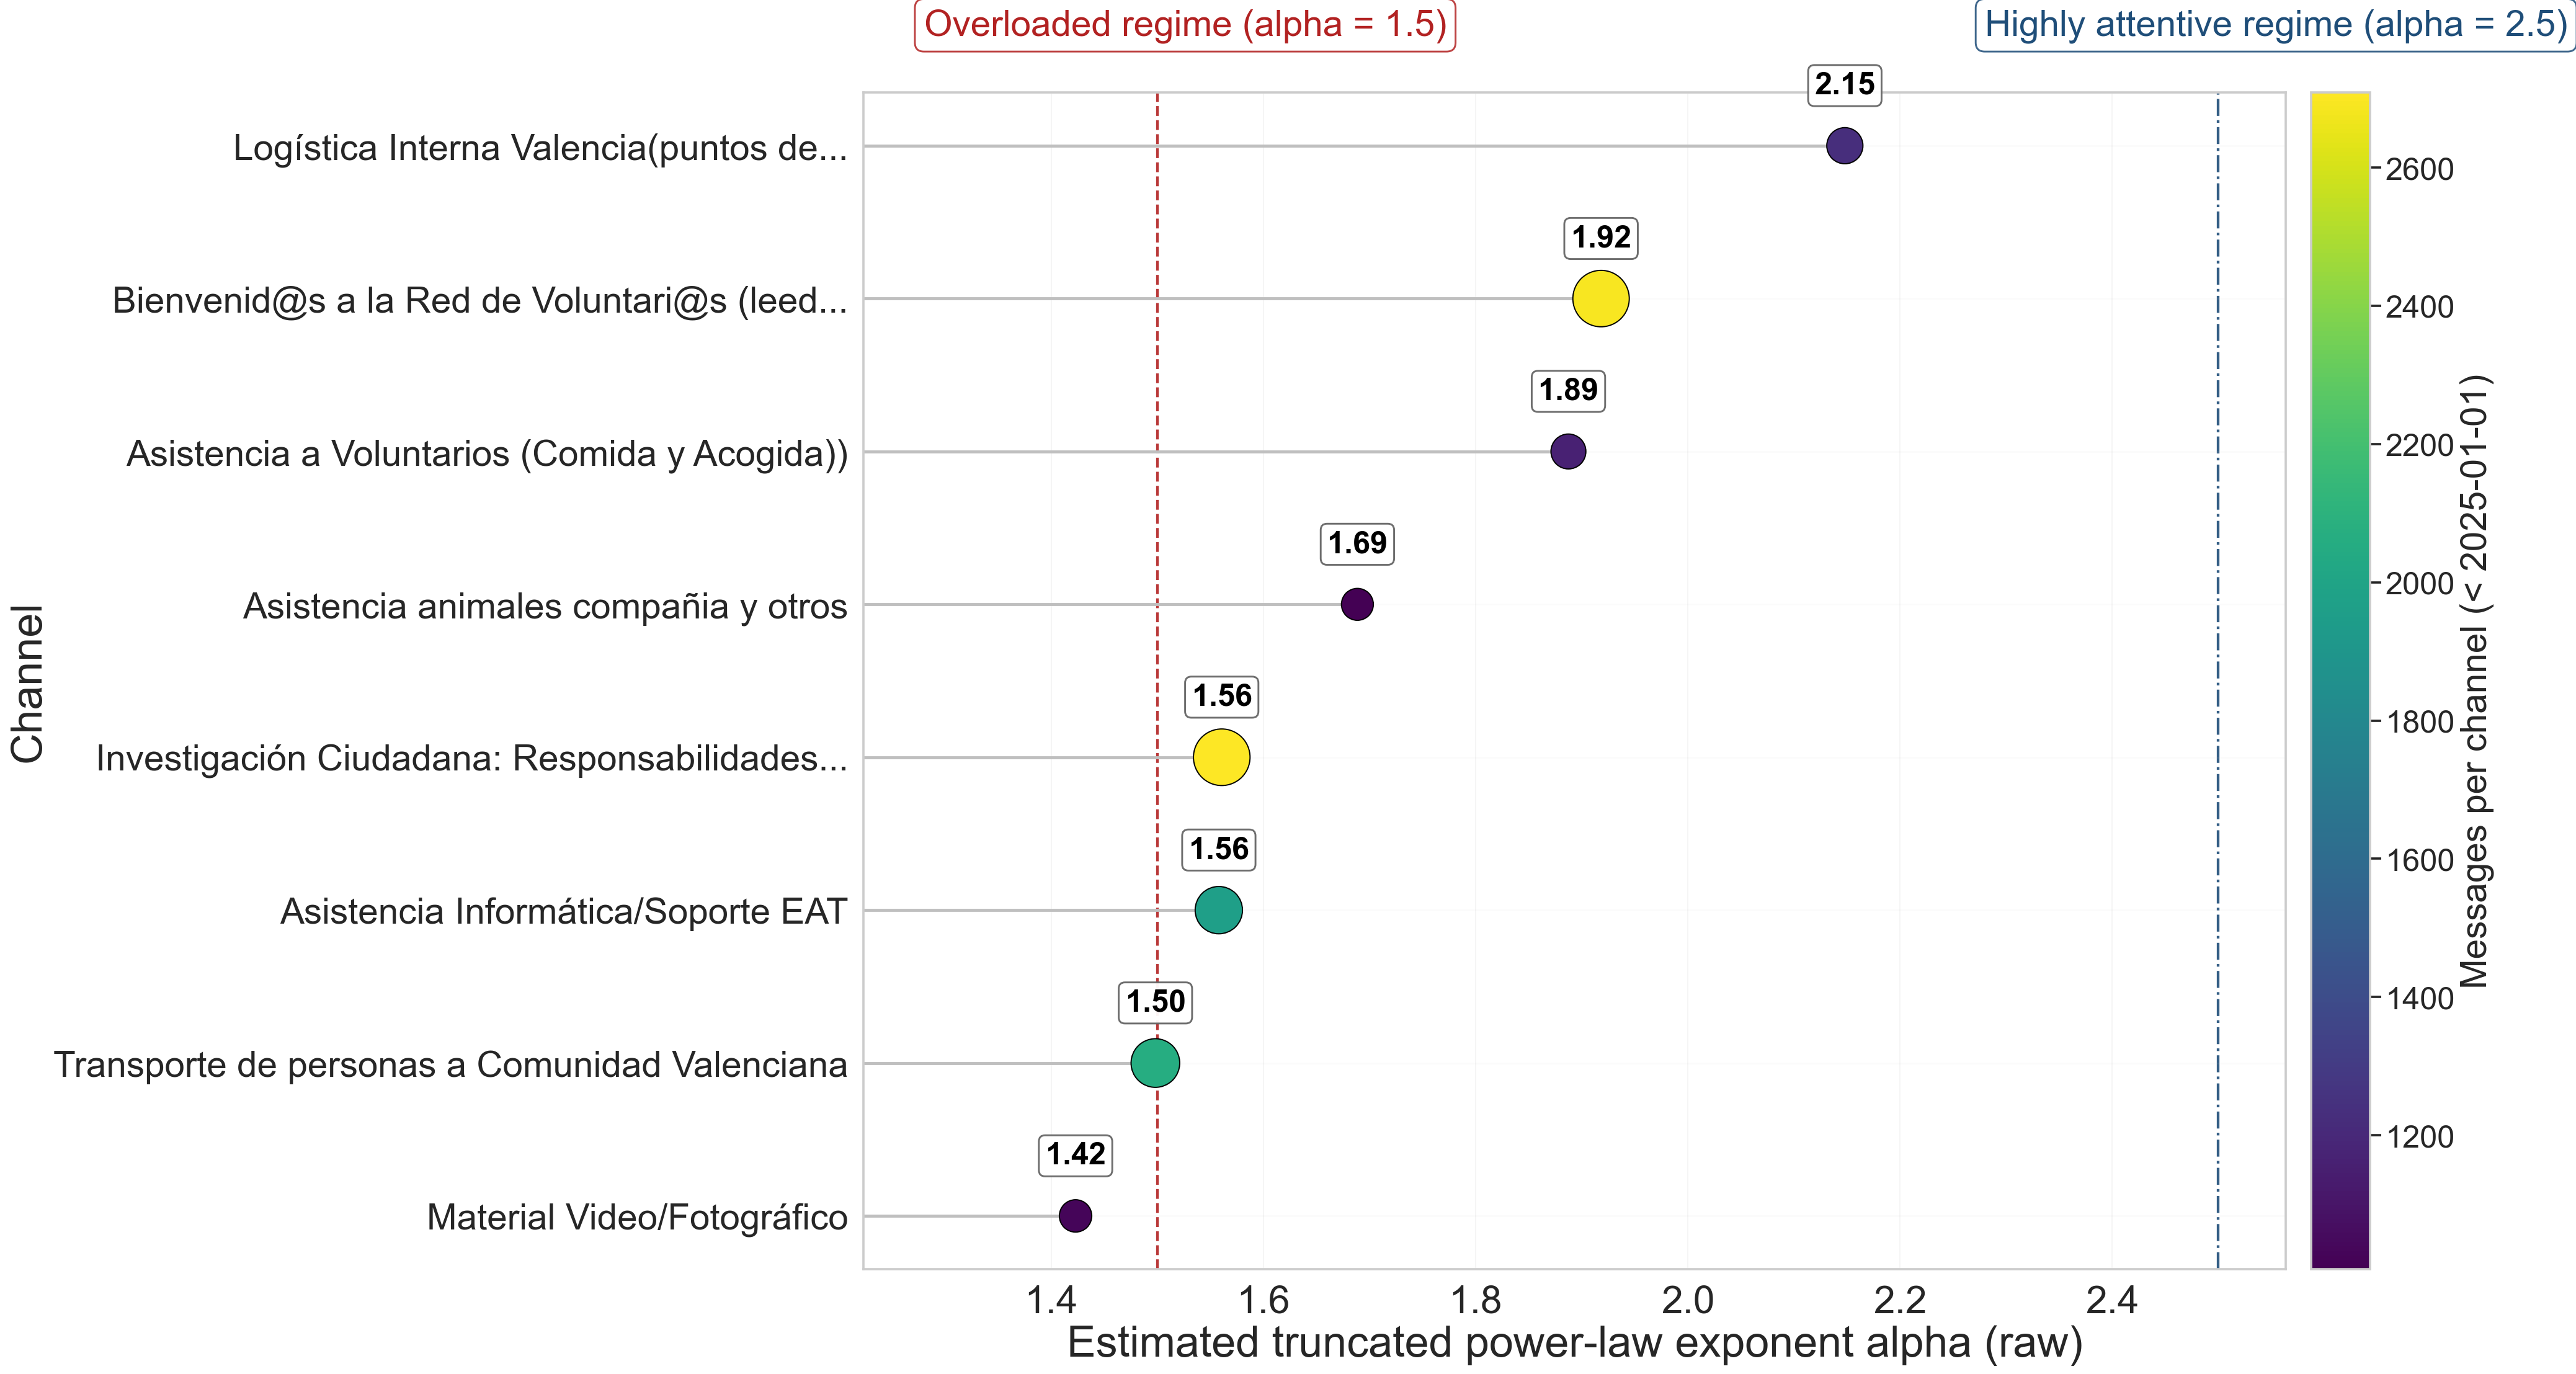

,channel,alpha_tpl,alpha_tpl_km,lambda_tpl_km,bias_sev,sigma_tpl,sigma_alpha_km,xmin,n_messages,n_waiting,n_tail
0,Material Video/Fotográfico,1.422932,1.642741,7.179153e-06,0.0507,NaN,0.007241,2954.0,1030,881,213
1,Transporte de personas a Comunidad Valenciana,1.498187,1.554366,2.735508e-05,0.0422,NaN,0.002056,789.0,2058,1978,518
2,Asistencia Informática/Soporte EAT,1.557988,1.572417,1.218618e-07,0.1072,NaN,0.000611,66.0,1960,1935,713
3,Investigación Ciudadana: Responsabilidades Pol...,1.560746,1.672142,3.738456e-06,0.0667,NaN,0.002271,1208.0,2709,2647,378
4,Asistencia animales compañia y otros,1.688625,1.732789,4.756749e-06,0.1693,NaN,0.004439,2789.0,1006,877,195
5,Asistencia a Voluntarios (Comida y Acogida)),1.887544,1.877816,4.649449e-07,0.2393,NaN,0.004870,919.0,1163,1135,244
6,Bienvenid@s a la Red de Voluntari@s (leed prim...,1.918309,1.904563,2.298134e-05,0.1876,NaN,0.003915,402.0,2695,2647,508
7,Logística Interna Valencia(puntos de recepción),2.148130,2.415631,7.576702e-07,0.0808,NaN,0.053332,26201.0,1231,1193,53


<Figure size 896x672 with 0 Axes>

In [8]:
# TPL analysis: truncated power-law exponents across channels (>1000 msgs), up to 2025-01-01.
from scipy.optimize import curve_fit

results_tpl = []
for channel in eligible_channels:
    ch = df_alpha.loc[df_alpha['topic_name'] == channel, ['date']].sort_values('date').copy()
    waiting = ch['date'].diff().dt.total_seconds().dropna()
    waiting = waiting[(waiting > 0) & np.isfinite(waiting)]

    # KM correction (before subsampling)
    T_seconds = (cutoff_date - ch['date'].iloc[0]).total_seconds()
    tau_fc    = max((cutoff_date - ch['date'].iloc[-1]).total_seconds(), 0.0)
    bias_sev  = waiting.max() / T_seconds

    iet_vals = waiting.values
    km_dur   = np.concatenate([iet_vals, iet_vals, [tau_fc]])
    km_obs   = np.concatenate([np.ones(len(iet_vals)), np.ones(len(iet_vals)), [0]])
    kmf = KaplanMeierFitter()
    kmf.fit(km_dur, event_observed=km_obs.astype(bool))

    if len(waiting) < 100:
        continue
    if len(waiting) > 6000:
        waiting = waiting.sample(6000, random_state=42).sort_values()

    try:
        fit      = powerlaw.Fit(waiting.values, discrete=True, verbose=False)
        tpl      = fit.truncated_power_law
        alpha_tpl  = float(getattr(tpl, 'alpha', np.nan))
        sigma_tpl  = float(getattr(tpl, 'sigma', np.nan))
        xmin       = float(getattr(tpl, 'xmin', np.nan))
        n_tail     = int(np.sum(waiting.values >= xmin)) if np.isfinite(xmin) else np.nan

        # KM-corrected TPL via curve_fit on survival curve
        # Model: S(τ) = (τ/xmin)^{-(α-1)} · exp(-(τ-xmin)·Λ), normalized to 1 at xmin
        km_t = kmf.survival_function_.index.values
        km_s = kmf.survival_function_['KM_estimate'].values
        mask = (km_t >= xmin) & (km_s > 0) & (km_t > 0)

        alpha_tpl_km  = np.nan
        lambda_tpl_km = np.nan
        sigma_alpha_km = np.nan
        if np.isfinite(xmin) and mask.sum() > 5:
            km_t_tail = km_t[mask]
            km_s_norm = km_s[mask] / km_s[mask][0]

            def tpl_surv(t, alpha, lam):
                return (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)

            try:
                popt, pcov = curve_fit(
                    tpl_surv, km_t_tail, km_s_norm,
                    p0=[max(alpha_tpl, 1.01), 1.0 / iet_vals.max()],
                    bounds=([1.001, 0.0], [20.0, np.inf]),
                    maxfev=10000
                )
                alpha_tpl_km, lambda_tpl_km = float(popt[0]), float(popt[1])
                sigma_alpha_km = float(np.sqrt(pcov[0, 0])) if np.isfinite(pcov[0, 0]) else np.nan
            except Exception:
                pass

        if np.isfinite(alpha_tpl):
            results_tpl.append({
                'channel':       channel,
                'alpha_tpl':     alpha_tpl,
                'alpha_tpl_km':  alpha_tpl_km,
                'lambda_tpl_km': lambda_tpl_km,
                'bias_sev':      round(bias_sev, 4),
                'sigma_tpl':     sigma_tpl if np.isfinite(sigma_tpl) else np.nan,
                'sigma_alpha_km': sigma_alpha_km,
                'xmin':          xmin,
                'n_messages':    int(channel_sizes[channel]),
                'n_waiting':     int(len(waiting)),
                'n_tail':        n_tail
            })
    except Exception as exc:
        print(f"Skipping channel: {channel} -> {exc}")

alpha_tpl_df = pd.DataFrame(results_tpl).sort_values('alpha_tpl', ascending=True).reset_index(drop=True)

if alpha_tpl_df.empty:
    raise ValueError('No valid TPL estimates could be computed.')

alpha_tpl_df['channel_label'] = alpha_tpl_df['channel'].apply(
    lambda s: textwrap.shorten(str(s), width=46, placeholder='...')
)

# --- Poster: TPL raw ---
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300,
    'axes.titlesize': 42, 'axes.labelsize': 36,
    'xtick.labelsize': 32, 'ytick.labelsize': 30,
})

fig, ax = plt.subplots(figsize=(30, 16))
plt.subplots_adjust(top=0.88, bottom=0.18)

x0 = max(0, alpha_tpl_df['alpha_tpl'].min() - 0.2)
for i, row in alpha_tpl_df.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_tpl'], color='0.75', linewidth=2.5, zorder=1)

sizes = np.interp(alpha_tpl_df['n_messages'],
                  (alpha_tpl_df['n_messages'].min(), alpha_tpl_df['n_messages'].max()), (700, 2200))
scatter = ax.scatter(alpha_tpl_df['alpha_tpl'], np.arange(len(alpha_tpl_df)),
                     s=sizes, c=alpha_tpl_df['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=1.0, zorder=3)

valid_sigma = alpha_tpl_df['sigma_tpl'].notna()
ax.errorbar(alpha_tpl_df.loc[valid_sigma, 'alpha_tpl'], np.where(valid_sigma)[0],
            xerr=alpha_tpl_df.loc[valid_sigma, 'sigma_tpl'],
            fmt='none', ecolor='0.25', elinewidth=1.5, capsize=5, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=2.2, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=2.2, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_tpl_df) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.25'))
ax.text(2.28, len(alpha_tpl_df) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=30, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.25'))

ax.set_yticks(np.arange(len(alpha_tpl_df)))
ax.set_yticklabels(alpha_tpl_df['channel_label'], fontsize=30)
ax.set_xlabel('Estimated truncated power-law exponent alpha (raw)', fontsize=36)
ax.set_ylabel('Channel', fontsize=36)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.8)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=30)
cbar.ax.tick_params(labelsize=26)

for i, row in alpha_tpl_df.iterrows():
    ax.annotate(f"{row['alpha_tpl']:.2f}", (row['alpha_tpl'], i),
                xytext=(0, 38), textcoords='offset points',
                va='bottom', ha='center', fontsize=26, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()
plt.savefig('alpha_tpl_poster.svg', format='svg', bbox_inches='tight')

alpha_tpl_df[['channel', 'alpha_tpl', 'alpha_tpl_km', 'lambda_tpl_km', 'bias_sev', 'sigma_tpl', 'sigma_alpha_km', 'xmin', 'n_messages', 'n_waiting', 'n_tail']]

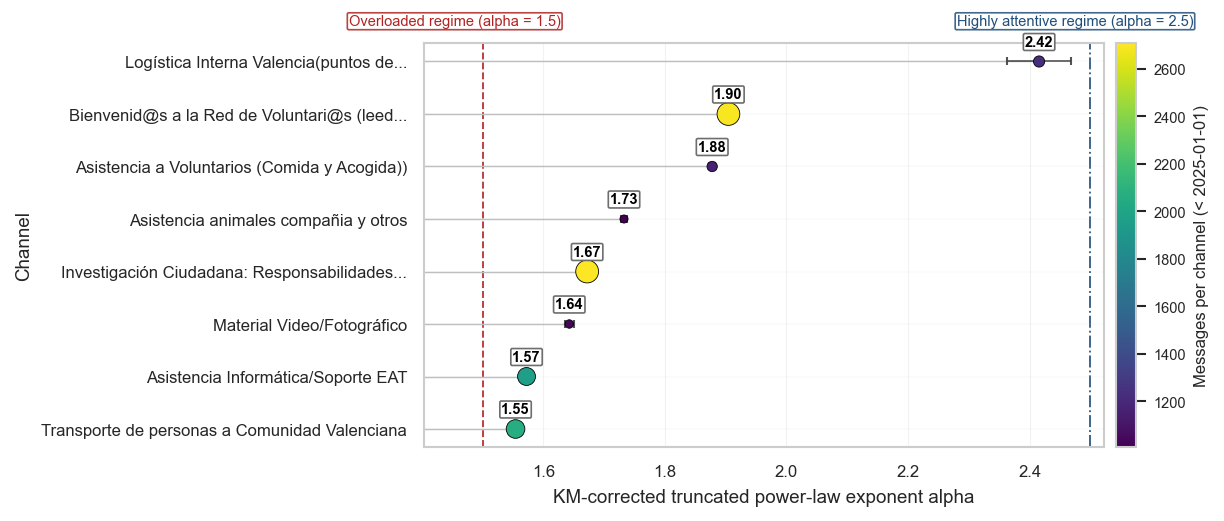

In [9]:
# Paper-ready: KM-corrected truncated power-law alpha

alpha_km_poster = alpha_tpl_df.dropna(subset=['alpha_tpl_km']).sort_values('alpha_tpl_km', ascending=True).reset_index(drop=True)
alpha_km_poster['channel_label'] = alpha_km_poster['channel'].apply(
    lambda s: __import__('textwrap').shorten(str(s), width=46, placeholder='...')
)

import seaborn as sns
import matplotlib as mpl
sns.set_theme(style='whitegrid', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

fig, ax = plt.subplots(figsize=(7, 3.5))

x0 = max(0, alpha_km_poster['alpha_tpl_km'].min() - 0.15)
for i, row in alpha_km_poster.iterrows():
    ax.hlines(y=i, xmin=x0, xmax=row['alpha_tpl_km'], color='0.75', linewidth=0.7, zorder=1)

sizes = np.interp(alpha_km_poster['n_messages'],
                  (alpha_km_poster['n_messages'].min(), alpha_km_poster['n_messages'].max()), (15, 120))
scatter = ax.scatter(alpha_km_poster['alpha_tpl_km'], np.arange(len(alpha_km_poster)),
                     s=sizes, c=alpha_km_poster['n_messages'], cmap='viridis',
                     edgecolor='black', linewidth=0.4, zorder=3)

valid_sigma = alpha_km_poster['sigma_alpha_km'].notna()
ax.errorbar(alpha_km_poster.loc[valid_sigma, 'alpha_tpl_km'], np.where(valid_sigma)[0],
            xerr=alpha_km_poster.loc[valid_sigma, 'sigma_alpha_km'],
            fmt='none', ecolor='0.25', elinewidth=0.8, capsize=2, zorder=2, alpha=0.9)

ax.axvline(1.5, color='#B22222', linestyle='--', linewidth=0.9, alpha=0.9, zorder=0)
ax.axvline(2.5, color='#1F4E79', linestyle='-.', linewidth=0.9, alpha=0.9, zorder=0)
ax.text(1.28, len(alpha_km_poster) - 0.1, 'Overloaded regime (alpha = 1.5)',
        color='#B22222', fontsize=7, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#B22222', alpha=0.85, boxstyle='round,pad=0.1'))
ax.text(2.28, len(alpha_km_poster) - 0.1, 'Highly attentive regime (alpha = 2.5)',
        color='#1F4E79', fontsize=7, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='#1F4E79', alpha=0.85, boxstyle='round,pad=0.1'))

ax.set_yticks(np.arange(len(alpha_km_poster)))
ax.set_yticklabels(alpha_km_poster['channel_label'], fontsize=8)
ax.set_xlabel('KM-corrected truncated power-law exponent alpha', fontsize=9)
ax.set_ylabel('Channel', fontsize=9)
ax.set_xlim(left=x0)
ax.grid(axis='x', alpha=0.25, linewidth=0.5)
ax.grid(axis='y', alpha=0.08)

cbar = plt.colorbar(scatter, ax=ax, pad=0.015)
cbar.set_label('Messages per channel (< 2025-01-01)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

for i, row in alpha_km_poster.iterrows():
    ax.annotate(f"{row['alpha_tpl_km']:.2f}", (row['alpha_tpl_km'], i),
                xytext=(0, 6), textcoords='offset points',
                va='bottom', ha='center', fontsize=7, color='black', fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='0.4', alpha=0.95, boxstyle='round,pad=0.1'))

fig.savefig('paper_alpha_tpl_km_voluntarios.pdf', format='pdf', bbox_inches='tight')
plt.show()
